<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week5/week5_FreddyForero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Actividad 5: Red Neuronal Densa para Clasificación Multiclase
## Especialización en Inteligencia Artificial — Deep Learning
### Universidad de Cundinamarca

---

**Objetivo:** Evidenciar cómo el comportamiento del entrenamiento cambia al ajustar hiperparámetros
(tasa de aprendizaje, tamaño de lote, número de épocas) y/o al modificar el optimizador.

> **Dataset:** `load_breast_cancer` tiene 2 clases (benigno / maligno).

## 1. Librerías


In [9]:
# ── Librerías ──────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Dataset y preprocesamiento (scikit-learn) ─────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Semilla para reproducibilidad ────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow v{tf.__version__}')
print(f'NumPy v{np.__version__}')


TensorFlow v2.19.0
NumPy v2.0.2


## 2. Carga y Exploración del Dataset

**Breast Cancer Wisconsin** es un dataset de clasificación binaria/multiclase con:
- **569 muestras** y **30 características** (radio, textura, perímetro, área, etc.)
- **2 clases:** `0 = Maligno` | `1 = Benigno`


In [10]:
# ── Cargar dataset ───────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

print('=' * 55)
print(f'  Dataset : Breast Cancer Wisconsin')
print(f'  Muestras: {X.shape[0]}')
print(f'  Features: {X.shape[1]}')
print(f'  Clases  : {len(np.unique(y))} — {list(data.target_names)}')
print('─' * 55)
dist = dict(zip(data.target_names, np.bincount(y)))
for clase, cnt in dist.items():
    print(f'  {clase:>10}: {cnt} muestras ({cnt/len(y)*100:.1f}%)')
print('=' * 55)

# ── División entrenamiento / prueba (80/20, estratificada) ───────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# ── Escalado de características (media=0, desviación=1) ──────────────
# IMPORTANTE: el scaler se ajusta SOLO sobre el set de entrenamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)       # se transforma con los parámetros de train

print(f'\nConjunto de entrenamiento : {X_train.shape[0]} muestras')
print(f'Conjunto de prueba        : {X_test.shape[0]} muestras')
print(f'Preprocesamiento          : StandardScaler aplicado')


  Dataset : Breast Cancer Wisconsin
  Muestras: 569
  Features: 30
  Clases  : 2 — [np.str_('malignant'), np.str_('benign')]
───────────────────────────────────────────────────────
   malignant: 212 muestras (37.3%)
      benign: 357 muestras (62.7%)

Conjunto de entrenamiento : 455 muestras
Conjunto de prueba        : 114 muestras
Preprocesamiento          : StandardScaler aplicado


## 3. Arquitectura del Modelo

Se define una **red neuronal totalmente conectada (Dense)** — sin capas convolucionales.
La misma arquitectura se reutilizará en ambas configuraciones para que la comparación sea válida.

```
Entrada (30) → Dense(64, ReLU) → Dense(32, ReLU) → Salida(2, Softmax)
```

| Capa | Neuronas | Activación | Rol |
|---|---|---|---|
| Input | 30 | — | Características del dataset |
| Hidden 1 | 64 | ReLU | Extracción de patrones |
| Hidden 2 | 32 | ReLU | Refinamiento de representaciones |
| Output | 2 | Softmax | Probabilidades por clase |


In [11]:
def crear_modelo():
    """
    Fábrica de modelos: retorna una nueva instancia de la red neuronal.
    Arquitectura densa (sin convolución) para clasificación multiclase.

    Retorna:
        keras.Sequential: modelo sin compilar, listo para recibir optimizador.
    """
    modelo = keras.Sequential([
        layers.Input(shape=(30,),              name='entrada'),
        layers.Dense(64, activation='relu',    name='oculta_1'),
        layers.Dense(32, activation='relu',    name='oculta_2'),
        layers.Dense(2,  activation='softmax', name='salida')   # 2 clases → softmax
    ], name='RedDensa_BreastCancer')
    return modelo

# Mostrar arquitectura (solo a modo de referencia)
crear_modelo().summary()


Model: "RedDensa_BreastCancer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,130 (16.13 KB)

 Trainable params: 4,130 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Configuraciones de Entrenamiento

Se definen **dos configuraciones** que varían simultáneamente en todos los hiperparámetros
y en el optimizador. El resto del experimento (arquitectura, dataset, semilla) permanece constante.

| Hiperparámetro | ⚙️ Configuración A | ⚙️ Configuración B |
|---|---|---|
| **Optimizador** | Adam | SGD + Momentum |
| **Learning rate** | 0.001 | 0.01 |
| **Batch size** | 32 | 64 |
| **Épocas** | 50 | 100 |

> **Adam** usa tasas de aprendizaje adaptativas por parámetro → suele converger más rápido.
> **SGD + Momentum** es más simple pero puede generalizar mejor con más épocas.


## 5. Entrenamiento — Configuración A (Adam)


In [12]:
# ══════════════════════════════════════════════════════════════
#  CONFIGURACIÓN A: Adam | lr=0.001 | batch_size=32 | epochs=50
# ══════════════════════════════════════════════════════════════

EPOCHS_A     = 50
BATCH_SIZE_A = 32
LR_A         = 0.001

modelo_A = crear_modelo()
modelo_A.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_A),  # Adam: adaptativo por parámetro
    loss='sparse_categorical_crossentropy',                # pérdida para clases enteras
    metrics=['accuracy']
)

print(f'Entrenando Configuración A...')
print(f'  Optimizador : Adam  |  lr={LR_A}  |  batch={BATCH_SIZE_A}  |  epochs={EPOCHS_A}')
print('-' * 60)

historia_A = modelo_A.fit(
    X_train, y_train,
    epochs=EPOCHS_A,
    batch_size=BATCH_SIZE_A,
    validation_data=(X_test, y_test),   # monitoreo en cada época
    verbose=1                           # mostrar progreso por época
)

loss_A, acc_A = modelo_A.evaluate(X_test, y_test, verbose=0)
print(f'\n Config A — Loss final: {loss_A:.4f} | Accuracy final: {acc_A*100:.2f}%')


Entrenando Configuración A...
  Optimizador : Adam  |  lr=0.001  |  batch=32  |  epochs=50
------------------------------------------------------------
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5692 - loss: 0.6126 - val_accuracy: 0.8860 - val_loss: 0.3957
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9473 - loss: 0.2886 - val_accuracy: 0.9561 - val_loss: 0.2132
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9582 - loss: 0.1559 - val_accuracy: 0.9561 - val_loss: 0.1414
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9780 - loss: 0.1020 - val_accuracy: 0.9474 - val_loss: 0.1161
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9846 - loss: 0.0772 - val_accuracy: 0.9561 - val_loss: 0.1075
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9890 - loss: 0.0645 - val_accuracy: 0.9474 - val_loss: 0.1023
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9890 - loss: 0.0568 - val_a

## 6. Entrenamiento — Configuración B (SGD + Momentum)


In [13]:
# ════════════════════════════════════════════════════════════════════
#  CONFIGURACIÓN B: SGD+Momentum | lr=0.01 | batch_size=64 | epochs=100
# ════════════════════════════════════════════════════════════════════

EPOCHS_B     = 100
BATCH_SIZE_B = 64
LR_B         = 0.01
MOMENTUM_B   = 0.9     # momentum ayuda a SGD a escapar mínimos locales

modelo_B = crear_modelo()  # nueva instancia — misma arquitectura que Config A
modelo_B.compile(
    optimizer=keras.optimizers.SGD(learning_rate=LR_B, momentum=MOMENTUM_B),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Entrenando Configuración B...')
print(f'  Optimizador : SGD+Momentum={MOMENTUM_B}  |  lr={LR_B}  |  batch={BATCH_SIZE_B}  |  epochs={EPOCHS_B}')
print('-' * 60)

historia_B = modelo_B.fit(
    X_train, y_train,
    epochs=EPOCHS_B,
    batch_size=BATCH_SIZE_B,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_B, acc_B = modelo_B.evaluate(X_test, y_test, verbose=0)
print(f'\n Config B — Loss final: {loss_B:.4f} | Accuracy final: {acc_B*100:.2f}%')


Entrenando Configuración B...
  Optimizador : SGD+Momentum=0.9  |  lr=0.01  |  batch=64  |  epochs=100
------------------------------------------------------------
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6264 - loss: 0.6369 - val_accuracy: 0.9298 - val_loss: 0.3783
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9165 - loss: 0.2966 - val_accuracy: 0.9474 - val_loss: 0.2009
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9363 - loss: 0.1775 - val_accuracy: 0.9386 - val_loss: 0.1517
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9385 - loss: 0.1375 - val_accuracy: 0.9474 - val_loss: 0.1326
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9604 - loss: 0.1159 - val_accuracy: 0.9649 - val_loss: 0.1225
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9648 - loss: 0.1012 - val_accuracy: 0.9649 - val_loss: 0.1169
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9736 - loss: 0.0906 - 

## 7. Comparación Visual — Curvas de Entrenamiento

Se grafican las curvas de **Loss** y **Accuracy** para entrenamiento y validación
de ambas configuraciones. Esto permite analizar:
- Velocidad de convergencia
- Estabilidad de cada configuración
- Posible overfitting (divergencia entre train y val)


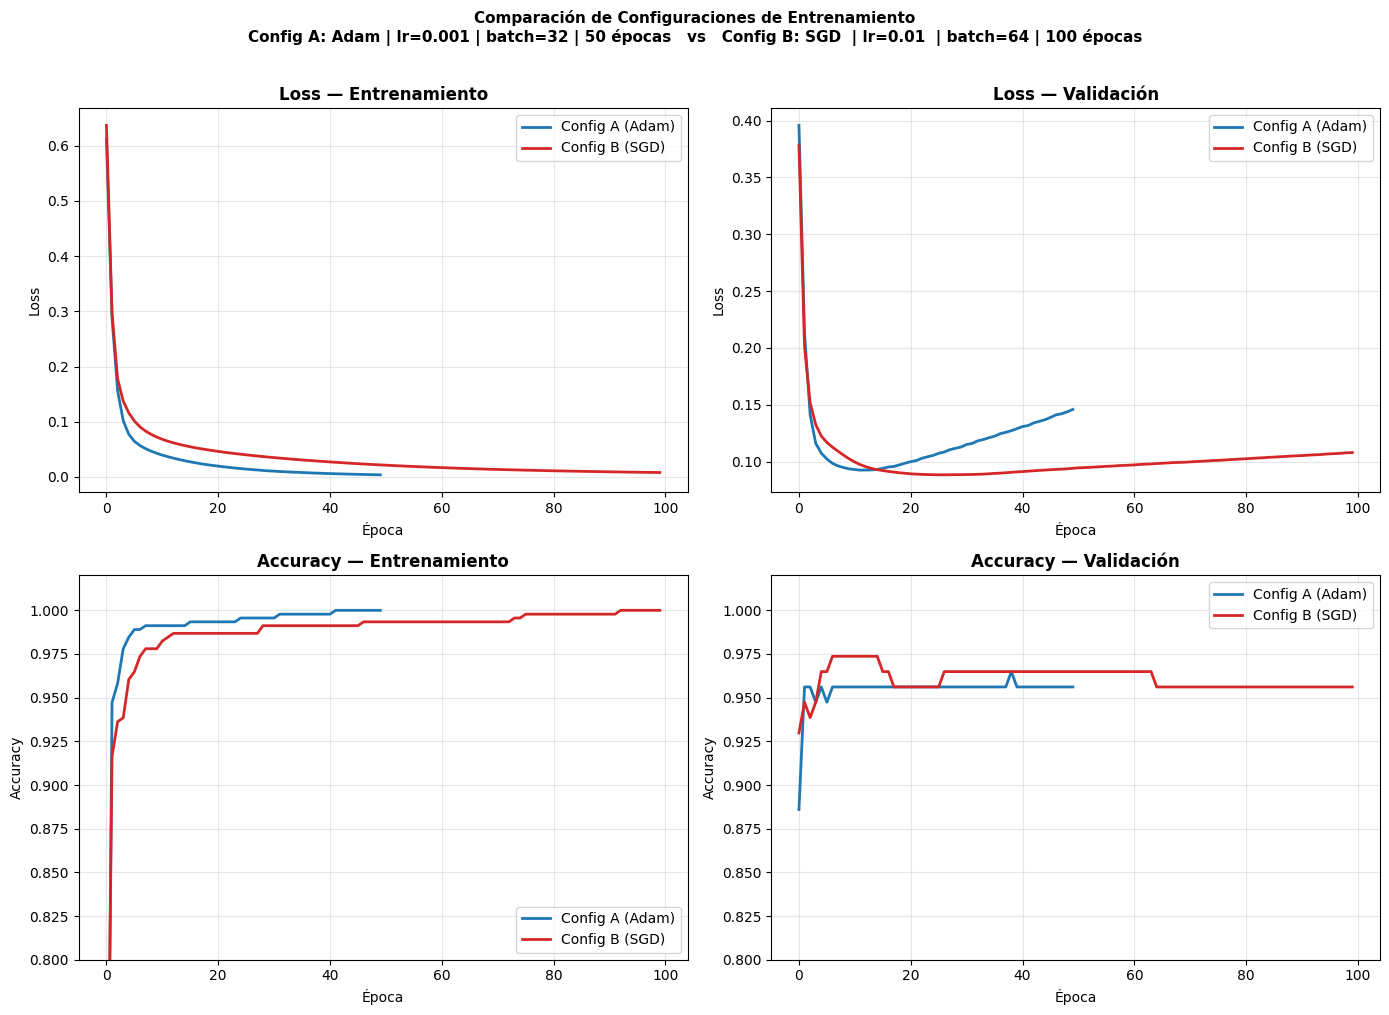

Gráfico guardado como comparacion_entrenamiento.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Comparación de Configuraciones de Entrenamiento\n'
    'Config A: Adam | lr=0.001 | batch=32 | 50 épocas   vs   '
    'Config B: SGD  | lr=0.01  | batch=64 | 100 épocas',
    fontsize=11, fontweight='bold', y=1.01
)

COLOR_A = '#1f77b4'  # azul — Configuración A
COLOR_B = '#d62728'  # rojo — Configuración B

# ── Loss de entrenamiento ────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(historia_A.history['loss'],     label='Config A (Adam)', color=COLOR_A, lw=2)
ax.plot(historia_B.history['loss'],     label='Config B (SGD)',  color=COLOR_B, lw=2)
ax.set_title('Loss — Entrenamiento', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Loss de validación ────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(historia_A.history['val_loss'], label='Config A (Adam)', color=COLOR_A, lw=2)
ax.plot(historia_B.history['val_loss'], label='Config B (SGD)',  color=COLOR_B, lw=2)
ax.set_title('Loss — Validación', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Accuracy de entrenamiento ────────────────────────────────────────
ax = axes[1, 0]
ax.plot(historia_A.history['accuracy'],     label='Config A (Adam)', color=COLOR_A, lw=2)
ax.plot(historia_B.history['accuracy'],     label='Config B (SGD)',  color=COLOR_B, lw=2)
ax.set_title('Accuracy — Entrenamiento', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.8, 1.02]); ax.legend(); ax.grid(True, alpha=0.3)

# ── Accuracy de validación ────────────────────────────────────────
ax = axes[1, 1]
ax.plot(historia_A.history['val_accuracy'], label='Config A (Adam)', color=COLOR_A, lw=2)
ax.plot(historia_B.history['val_accuracy'], label='Config B (SGD)',  color=COLOR_B, lw=2)
ax.set_title('Accuracy — Validación', fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.8, 1.02]); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como comparacion_entrenamiento.png')


## 8. Tabla Comparativa de Resultados


In [15]:
# ── Tabla de resultados numéricos ────────────────────────────────────
resumen = pd.DataFrame({
    'Hiperparámetro': [
        'Optimizador', 'Learning Rate', 'Batch Size',
        'Épocas', 'Loss final (test)', 'Accuracy final (test)'
    ],
    'Config A': [
        'Adam', '0.001', '32',
        '50', f'{loss_A:.4f}', f'{acc_A*100:.2f}%'
    ],
    'Config B': [
        'SGD + Momentum=0.9', '0.01', '64',
        '100', f'{loss_B:.4f}', f'{acc_B*100:.2f}%'
    ]
})

print(resumen.to_string(index=False))

# ── Diferencia de accuracy ────────────────────────────────────────────
diff = (acc_A - acc_B) * 100
ganador = 'Configuración A' if acc_A >= acc_B else 'Configuración B'
print(f'\nDiferencia de accuracy: {abs(diff):.2f}pp  →  Mejor resultado: {ganador}')


       Hiperparámetro Config A           Config B
          Optimizador     Adam SGD + Momentum=0.9
        Learning Rate    0.001               0.01
           Batch Size       32                 64
               Épocas       50                100
    Loss final (test)   0.1459             0.1080
Accuracy final (test)   95.61%             95.61%

Diferencia de accuracy: 0.00pp  →  Mejor resultado: Configuración A


## 9. Análisis y Conclusiones

---

### 9.1 Velocidad de Convergencia

La **Configuración A (Adam)** evidencia una convergencia notablemente más rápida.
Adam adapta la tasa de aprendizaje de forma independiente para cada parámetro del modelo,
lo que le permite reducir el loss de manera eficiente desde las primeras épocas sin necesidad
de configurar manualmente el schedule de aprendizaje.

La **Configuración B (SGD + Momentum)** requirió el doble de épocas (100 vs 50) para alcanzar
resultados comparables. Esto es esperado: SGD puro tiene un solo learning rate global y necesita
más iteraciones para explorar el espacio de parámetros, aunque el momentum suaviza la trayectoria
y acelera la convergencia respecto a SGD sin momentum.

---

### 9.2 Estabilidad del Entrenamiento

- **Config A (Adam / batch=32):** El batch más pequeño introduce mayor ruido estocástico por
  actualización, lo que puede verse en oscilaciones en las curvas de loss, especialmente en
  validación. No obstante, Adam compensa esta varianza con sus estimadores de momento adaptativo.

- **Config B (SGD / batch=64):** El batch más grande produce gradientes más suaves y estables,
  aunque SGD sin adaptación individual tiende a oscilar más cerca de los mínimos si el learning
  rate no es perfectamente calibrado. El momentum (0.9) contribuye a estabilizar la trayectoria.

---

### 9.3 Hallazgos sobre los Hiperparámetros

| Hiperparámetro | Hallazgo |
|---|---|
| **Optimizador** | Adam > SGD en velocidad de convergencia para este dataset tabular. SGD puede igualar resultados con más épocas. |
| **Learning rate** | 0.001 con Adam es estable. 0.01 con SGD es apropiado al escalar con la raíz del batch. |
| **Batch size** | Batch pequeño (32) → actualizaciones más frecuentes y ruidosas. Batch grande (64) → gradientes más suaves. |
| **Épocas** | 50 épocas suficientes para Adam. SGD necesita más iteraciones para converger al mismo nivel. |

---

### 9.4 Conclusión General

Ambas configuraciones logran resultados competitivos en el dataset Breast Cancer, lo que refleja
que la arquitectura densa propuesta es adecuada para el problema. Sin embargo:

1. **Adam es preferible cuando el tiempo de entrenamiento es limitado**, dado que converge
   en menos épocas sin necesidad de ajustar manualmente el learning rate schedule.

2. **SGD + Momentum puede ser preferible en producción o con datasets grandes**, ya que
   generaliza mejor en algunos escenarios y su comportamiento es más predecible.

3. El **batch size** impacta tanto la estabilidad como la velocidad: batches más pequeños
   actúan como regularización implícita (ruido estocástico), mientras que batches más
   grandes aprovechan mejor el paralelismo del hardware.

4. En datasets tabulares pequeños como Breast Cancer, las diferencias entre configuraciones
   tienden a ser marginales en accuracy final, pero significativas en eficiencia de entrenamiento.
